# **Road Traffic Accident Analysis, Risk Segmentation & Prediction using ML models (India 2022)**

### **🚀Importing Relevant Libraries**

In [ ]:
# ================================
# 1. Basic Libraries
# ================================
import numpy as np
import pandas as pd
# ================================
# 2. Visualization Libraries
# ================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
# ================================
# 3. Warning Suppression
# ================================
import warnings
warnings.filterwarnings("ignore")
# ================================
# 4. Data Preprocessing
# ================================
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler
)
from sklearn.impute import SimpleImputer
# ================================
# 5. Train-Test Split
# ================================
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)
# ================================
# 6. Regression Models
# ================================
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# ================================
# 7. Clustering Models
# ================================
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)
# ================================
# 8. Dimensionality Reduction
# ================================
from sklearn.decomposition import PCA
# ================================
# 9. Evaluation Metrics
# ================================
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    silhouette_score
)
# ================================
# 10. Statistical Analysis
# ================================
from scipy.stats import zscore
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# ================================
# 11. Utilities
# ================================
import os
import gc

### **🧠Data Loading**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/accidents_reported_2022_new_data_mlp_project2.csv')
print(data.head())

  Sl. No.      State/UT/City  Road Accidents - Cases  \
0       1     Andhra Pradesh                   21070   
1       2  Arunachal Pradesh                     215   
2       3              Assam                    7028   
3       4              Bihar                   10801   
4       5       Chhattisgarh                   13091   

   Road Accidents - Injured  Road Accidents - Died  Railway Accidents - Cases  \
0                     21340                   8293                       1029   
1                       177                    152                          0   
2                      5679                   3060                        689   
3                      7068                   8898                       1444   
4                     11459                   5890                        429   

   Railway Accidents - Injured  Railway Accidents - Died  \
0                            0                      1037   
1                            0                         0

### **🔍Data Description**

In [ ]:
print(data.shape)

(93, 14)


In [ ]:
print(data.columns)

Index(['Sl. No.', 'State/UT/City', 'Road Accidents - Cases',
       'Road Accidents - Injured', 'Road Accidents - Died',
       'Railway Accidents - Cases', 'Railway Accidents - Injured',
       'Railway Accidents - Died', 'Railway Crossing Accidents - Cases',
       'Railway Crossing Accidents - Injured',
       'Railway Crossing Accidents - Died', 'Total Traffic Accidents - Cases',
       'Total Traffic Accidents - Injured', 'Total Traffic Accidents - Died'],
      dtype='object')


In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Sl. No.                               93 non-null     object
 1   State/UT/City                         93 non-null     object
 2   Road Accidents - Cases                93 non-null     int64 
 3   Road Accidents - Injured              93 non-null     int64 
 4   Road Accidents - Died                 93 non-null     int64 
 5   Railway Accidents - Cases             93 non-null     int64 
 6   Railway Accidents - Injured           93 non-null     int64 
 7   Railway Accidents - Died              93 non-null     int64 
 8   Railway Crossing Accidents - Cases    93 non-null     int64 
 9   Railway Crossing Accidents - Injured  93 non-null     int64 
 10  Railway Crossing Accidents - Died     93 non-null     int64 
 11  Total Traffic Accidents - Cases   

In [ ]:
print(data.isnull().sum())

Sl. No.                                 0
State/UT/City                           0
Road Accidents - Cases                  0
Road Accidents - Injured                0
Road Accidents - Died                   0
Railway Accidents - Cases               0
Railway Accidents - Injured             0
Railway Accidents - Died                0
Railway Crossing Accidents - Cases      0
Railway Crossing Accidents - Injured    0
Railway Crossing Accidents - Died       0
Total Traffic Accidents - Cases         0
Total Traffic Accidents - Injured       0
Total Traffic Accidents - Died          0
dtype: int64


**Hence, there are no missing values present in this Dataset.**

### **💡Exploratory Data Analysis(EDA)**

### **🔥(a) Bar Chart**

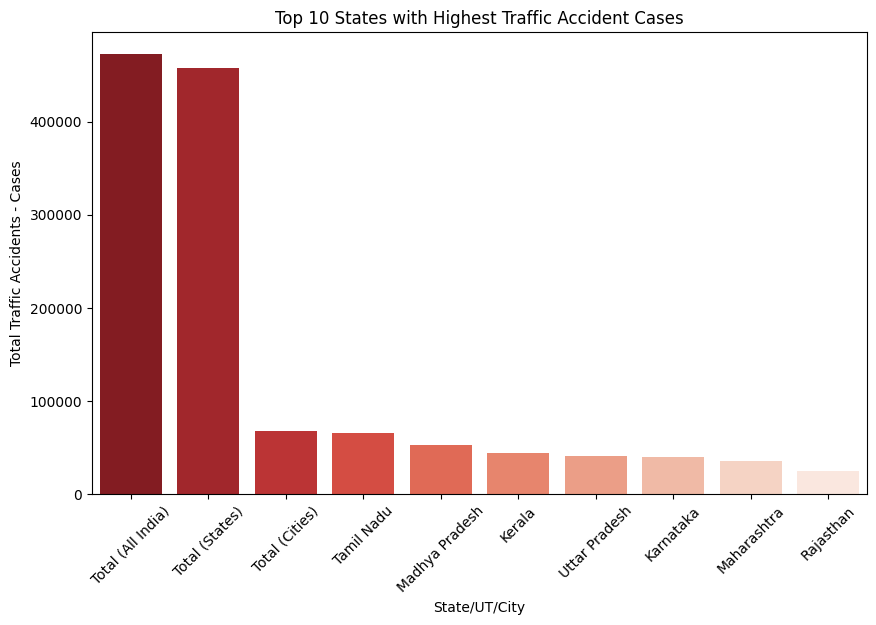

In [ ]:
plt.figure(figsize=(10,6))
top_states = data.sort_values(
    by='Total Traffic Accidents - Cases',
    ascending=False
).head(10)

sns.barplot(
    x='State/UT/City',
    y='Total Traffic Accidents - Cases',
    data=top_states,
    palette='Reds_r'
)
plt.xticks(rotation=45)
plt.title('Top 10 States with Highest Traffic Accident Cases')
plt.show()

### **🔥(b) Pie Chart**

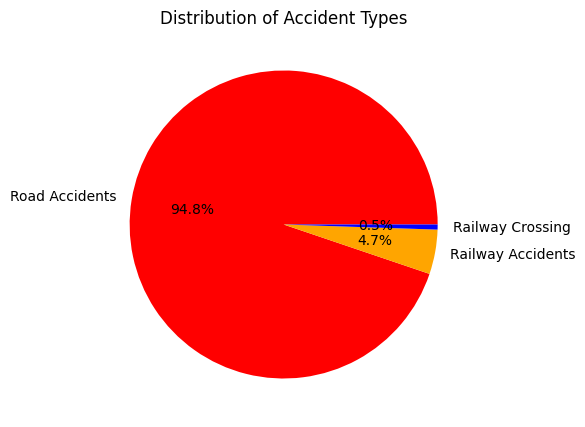

In [ ]:
accident_types = [
    data['Road Accidents - Cases'].sum(),
    data['Railway Accidents - Cases'].sum(),
    data['Railway Crossing Accidents - Cases'].sum()
]
labels = [
    'Road Accidents',
    'Railway Accidents',
    'Railway Crossing'
]
plt.figure(figsize=(5,5))
plt.pie(
    accident_types,
    labels=labels,
    autopct='%1.1f%%',
    colors=['red','orange','blue']
)
plt.title('Distribution of Accident Types')
plt.show()

### **🔥(c) Histogram Chart(Distribution of Death Cases)**





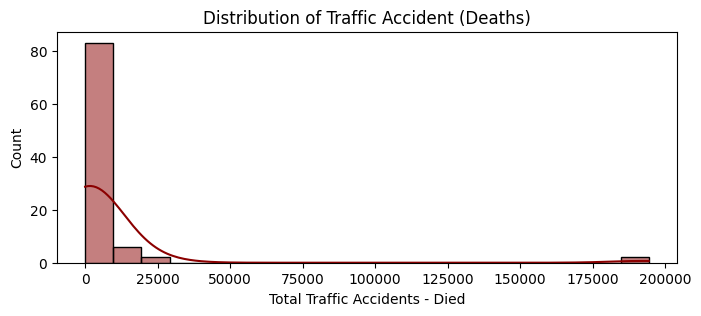

In [ ]:
plt.figure(figsize=(8,3))

sns.histplot(
    data['Total Traffic Accidents - Died'],
    bins=20,
    kde=True,
    color='darkred'
)

plt.title('Distribution of Traffic Accident (Deaths)')
plt.show()

### **🔥(d) Correlation Heatmap**

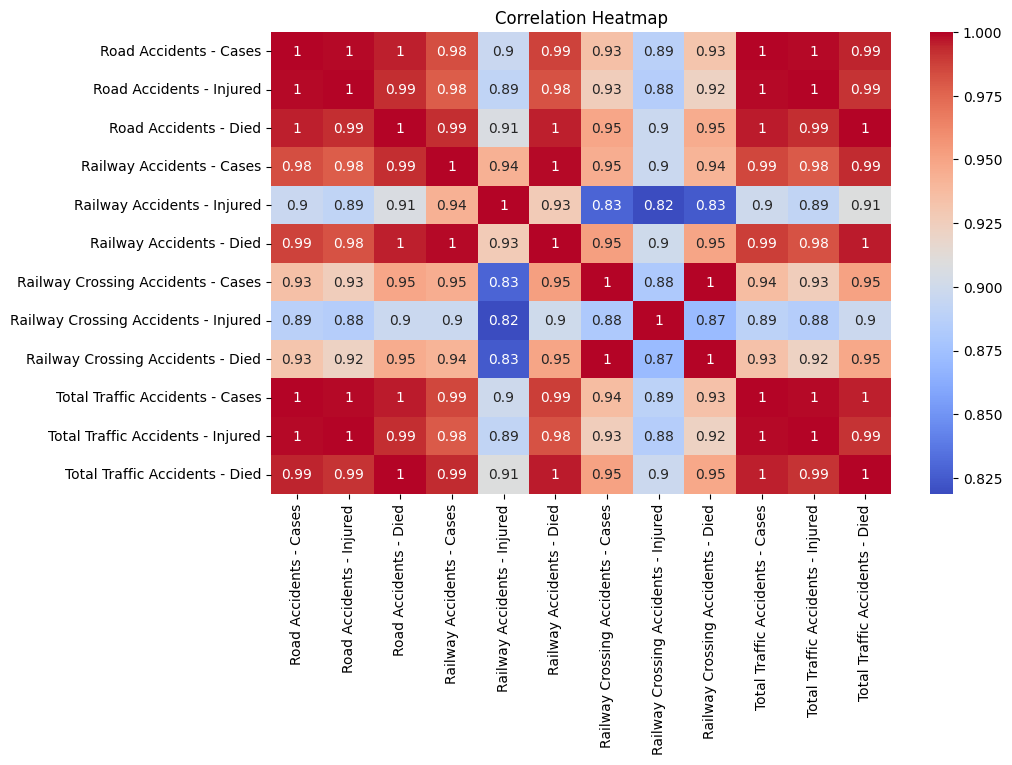

In [ ]:
plt.figure(figsize=(10,6))

numeric_data = data.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

### **🔥(e) Pair Plot**

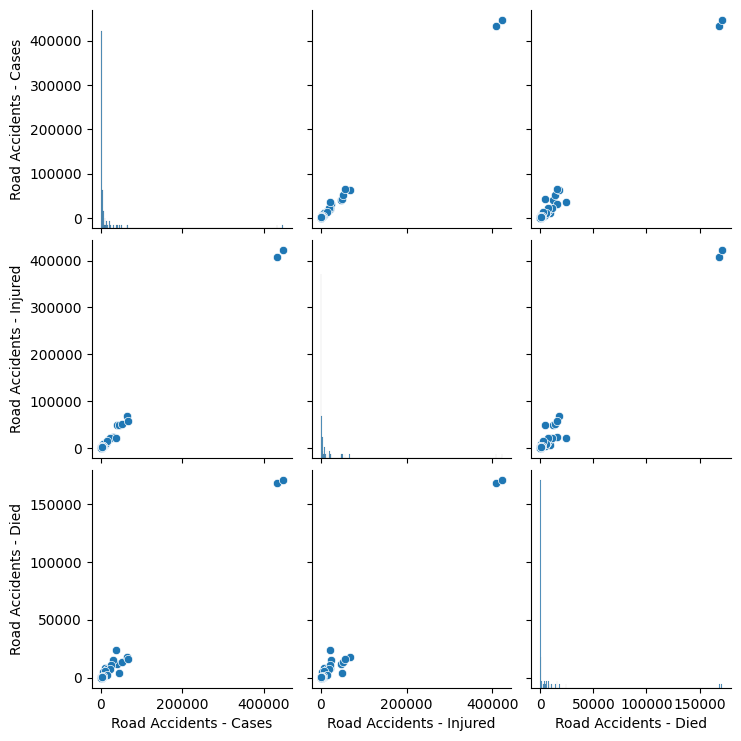

In [ ]:
sns.pairplot(
    data[
        [
            'Road Accidents - Cases',
            'Road Accidents - Injured',
            'Road Accidents - Died'
        ]
    ]
)
plt.show()

### **🔥(f) Box Plot(Outlier Detection)**

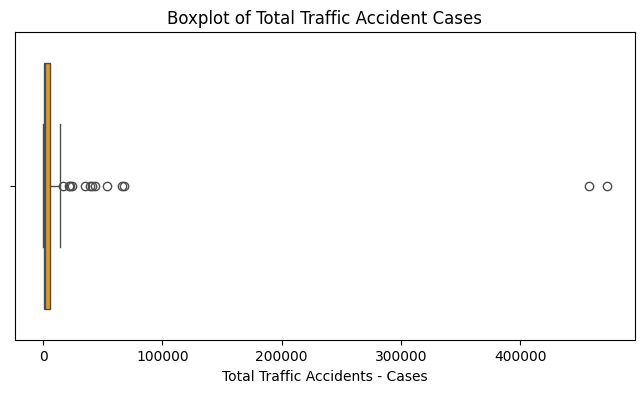

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=data['Total Traffic Accidents - Cases'],
    color='orange'
)

plt.title('Boxplot of Total Traffic Accident Cases')
plt.show()

### **🔥(g) Scatter Plot(Injuries vs Deaths)**

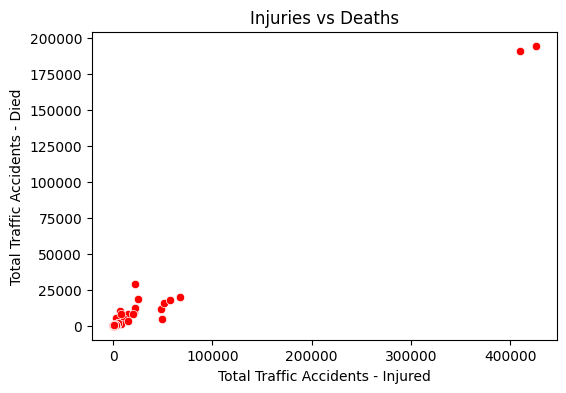

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='Total Traffic Accidents - Injured',
    y='Total Traffic Accidents - Died',
    data=data,
    color='red'
)

plt.title('Injuries vs Deaths')
plt.show()

### **🔥(h) Line Plot(Trend-style Comparison)**

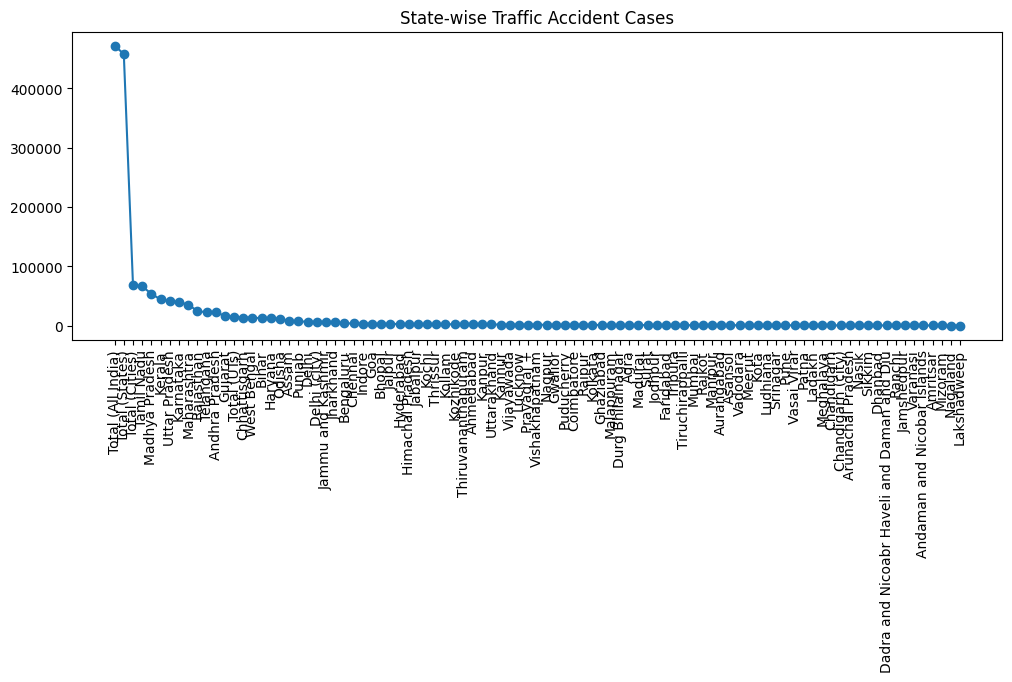

In [ ]:
sorted_data = data.sort_values(
    by='Total Traffic Accidents - Cases',
    ascending=False
)

plt.figure(figsize=(12,4))

plt.plot(
    sorted_data['State/UT/City'],
    sorted_data['Total Traffic Accidents - Cases'],
    marker='o'
)

plt.xticks(rotation=90)
plt.title('State-wise Traffic Accident Cases')
plt.show()

## **Data Pre-processing**

### **Cleaning Column Names**

In [ ]:
data.columns = data.columns.str.strip()
data.columns = data.columns.str.replace(" ", "_")

### **Converting Categorical Columns**

In [ ]:
le = LabelEncoder()
data['State/UT/City_Encoded'] = le.fit_transform(data['State/UT/City'])
print(data[['State/UT/City', 'State/UT/City_Encoded']].head())

       State/UT/City  State/UT/City_Encoded
0     Andhra Pradesh                      4
1  Arunachal Pradesh                      5
2              Assam                      7
3              Bihar                     11
4       Chhattisgarh                     15


### **Feature Scaling(using Standard Scaler)**

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    data.select_dtypes(include=['int64','float64']))

## **Feature Engineering**

**(a) Total Casualty Feature**

In [ ]:
print(data.columns)

Index(['Sl._No.', 'State/UT/City', 'Road_Accidents_-_Cases',
       'Road_Accidents_-_Injured', 'Road_Accidents_-_Died',
       'Railway_Accidents_-_Cases', 'Railway_Accidents_-_Injured',
       'Railway_Accidents_-_Died', 'Railway_Crossing_Accidents_-_Cases',
       'Railway_Crossing_Accidents_-_Injured',
       'Railway_Crossing_Accidents_-_Died', 'Total_Traffic_Accidents_-_Cases',
       'Total_Traffic_Accidents_-_Injured', 'Total_Traffic_Accidents_-_Died',
       'State/UT/City_Encoded'],
      dtype='object')


In [ ]:
data['Total_Casualties'] = (
    data['Total_Traffic_Accidents_-_Injured'] + data['Total_Traffic_Accidents_-_Died']
)
print(data['Total_Casualties'])

0     30670
1       329
2      9454
3     17471
4     17803
      ...  
88      260
89      378
90     1785
91     1646
92    74926
Name: Total_Casualties, Length: 93, dtype: int64


**(b) Fatality Ratio**

In [ ]:
data['Fatality_Ratio'] = (
    data['Total_Traffic_Accidents_-_Died'] /
    (data['Total_Traffic_Accidents_-_Cases'] + 1)
)
print(data['Fatality_Ratio'])

0     0.422172
1     0.703704
2     0.487726
3     0.845422
4     0.467505
        ...   
88    1.067485
89    0.481050
90    0.270725
91    0.264597
92    0.259097
Name: Fatality_Ratio, Length: 93, dtype: float64


**(c) Injury Severity Score**

In [ ]:
data['Severity_Score'] = (
    data['Total_Traffic_Accidents_-_Died'] * 2 +
    data['Total_Traffic_Accidents_-_Injured']
)
print(data['Severity_Score'])

0     40000
1       481
2     13229
3     27868
4     24126
      ...  
88      434
89      543
90     2203
91     2004
92    92606
Name: Severity_Score, Length: 93, dtype: int64


**(d) Accident Density Categories**

In [ ]:
data['Risk_Level'] = pd.qcut(
    data['Total_Traffic_Accidents_-_Cases'],
    q=3,
    labels=['Low','Medium','High']
)

**(e) State-wise Ranking**

In [ ]:
data['Accident_Rank'] = (
    data['Total_Traffic_Accidents_-_Cases']
    .rank(ascending=False)
)
print(data['Accident_Rank'])

0     12.0
1     81.0
2     20.0
3     17.0
4     15.0
      ... 
88    88.0
89    75.0
90    44.0
91    47.0
92     3.0
Name: Accident_Rank, Length: 93, dtype: float64


## **Model Building**

In [ ]:
X = data[
    [
        'Road_Accidents_-_Cases',
        'Road_Accidents_-_Injured',
        'Road_Accidents_-_Died',

        'Railway_Accidents_-_Cases',
        'Railway_Accidents_-_Injured',
        'Railway_Accidents_-_Died',

        'Railway_Crossing_Accidents_-_Cases',
        'Railway_Crossing_Accidents_-_Injured',
        'Railway_Crossing_Accidents_-_Died',

        'State/UT/City_Encoded'
    ]
]
y = data['Total_Traffic_Accidents_-_Cases']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### **(a) Linear Regression Model**

In [ ]:
lr_model = LinearRegression()
# ================================
# Train Model
# ================================
lr_model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [ ]:
y_pred = lr_model.predict(X_test)

**Evaluation of Model**

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_linear = r2_score(y_test, y_pred)
# ================================
# Print Scores
# ================================
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2_linear)

MAE : 2.016912952441137e-11
MSE : 2.9993140568359458e-21
RMSE : 5.476599361680518e-11
R2 Score : 1.0


**Actual Vs Predicted Plot**

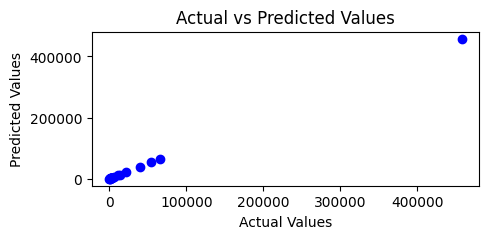

In [ ]:
plt.figure(figsize=(5,2))
plt.scatter(
    y_test,
    y_pred,
    color='blue'
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

**Residual Plot**

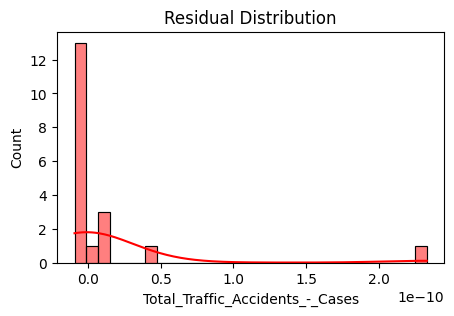

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(5,3))
sns.histplot(
    residuals,
    kde=True,
    color='red'
)
plt.title("Residual Distribution")
plt.show()

### **(b) Ridge Regression Model**

In [ ]:
ridge_model = Ridge(
    alpha=1.0,
    random_state=42
)
ridge_model.fit(X_train, y_train)
print("Ridge Regression Model Trained Successfully")

Ridge Regression Model Trained Successfully


In [ ]:
y_pred_ridge = ridge_model.predict(X_test)

**Evaluation of Model**

In [ ]:
# MAE
mae = mean_absolute_error(y_test, y_pred_ridge)
# MSE
mse = mean_squared_error(y_test, y_pred_ridge)
# RMSE
rmse = np.sqrt(mse)
# R² Score
r2_ridge = r2_score(y_test, y_pred_ridge)
print("Ridge Regression Results")
print("-"*40)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2_ridge)

Ridge Regression Results
----------------------------------------
MAE : 0.09495130891051332
MSE : 0.023992150556576698
RMSE : 0.15489399780681207
R² Score : 0.9999999999976563


**Actual Vs Predicted Plot**

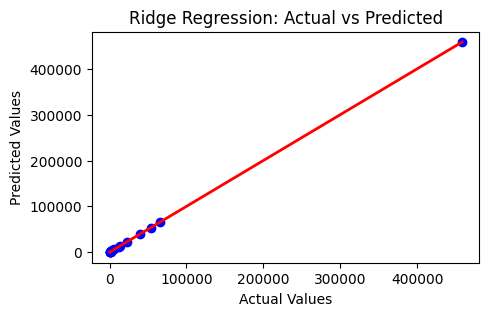

In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(
    y_test,
    y_pred_ridge,
    color='blue'
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()

**Residual Plot**

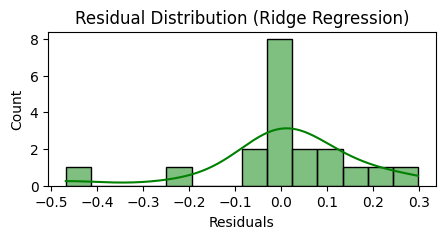

In [ ]:
residuals = y_test - y_pred_ridge
plt.figure(figsize=(5,2))
sns.histplot(
    residuals,
    kde=True,
    color='green'
)
plt.title("Residual Distribution (Ridge Regression)")
plt.xlabel("Residuals")
plt.show()

**Residual Scatter Plot**

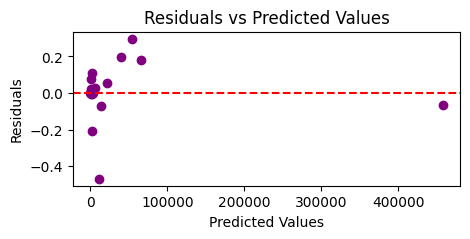

In [ ]:
plt.figure(figsize=(5,2))
plt.scatter(
    y_pred_ridge,
    residuals,
    color='purple'
)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

In [ ]:
ridge_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_model.coef_
})

ridge_coefficients

,Feature,Coefficient
0,Road_Accidents_-_Cases,1.000017
1,Road_Accidents_-_Injured,-0.000019
2,Road_Accidents_-_Died,0.000002
3,Railway_Accidents_-_Cases,0.996191
4,Railway_Accidents_-_Injured,0.003847
5,Railway_Accidents_-_Died,0.003756
6,Railway_Crossing_Accidents_-_Cases,0.784152
7,Railway_Crossing_Accidents_-_Injured,0.224190
8,Railway_Crossing_Accidents_-_Died,0.215070
9,State/UT/City_Encoded,0.000145


### **(c) Random Forest Regression Model**

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [ ]:
y_pred_rf = rf_model.predict(X_test)

**Evaluation of Model**

In [ ]:
# MAE
mae = mean_absolute_error(y_test, y_pred_rf)
# MSE
mse = mean_squared_error(y_test, y_pred_rf)
# RMSE
rmse = np.sqrt(mse)
# R² Score
r2_random = r2_score(y_test, y_pred_rf)
print("Random Forest Regression Results")
print("-"*40)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2_random)

Random Forest Regression Results
----------------------------------------
MAE : 12258.68894736842
MSE : 1991438446.0444264
RMSE : 44625.5358068049
R² Score : 0.8054646066088731


**Actual Vs Predicted Plot**

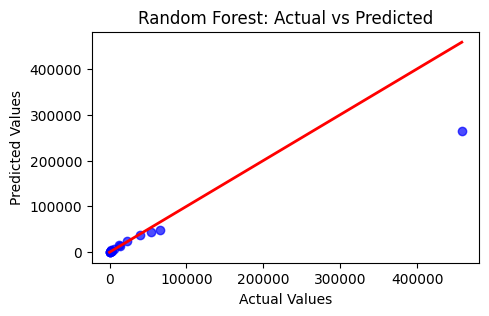

In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(
    y_test,
    y_pred_rf,
    color='blue',
    alpha=0.7
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

**Residual Plot**

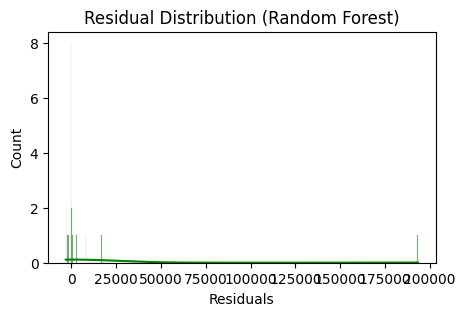

In [ ]:
residuals_rf = y_test - y_pred_rf
plt.figure(figsize=(5,3))
sns.histplot(
    residuals_rf,
    kde=True,
    color='green'
)
plt.title("Residual Distribution (Random Forest)")
plt.xlabel("Residuals")
plt.show()

**Residual Scatter Plot**

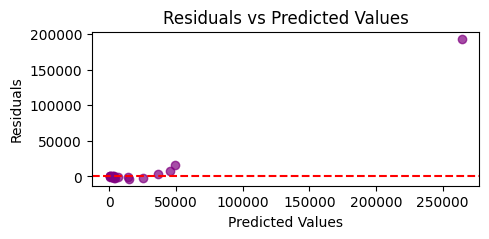

In [ ]:
plt.figure(figsize=(5,2))
plt.scatter(
    y_pred_rf,
    residuals_rf,
    color='purple',
    alpha=0.7
)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

**Feature Importance**

In [ ]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance_df)

                                Feature  Importance
0                Road_Accidents_-_Cases    0.269945
1              Road_Accidents_-_Injured    0.239631
3             Railway_Accidents_-_Cases    0.095954
7  Railway_Crossing_Accidents_-_Injured    0.094559
6    Railway_Crossing_Accidents_-_Cases    0.082823
4           Railway_Accidents_-_Injured    0.079185
2                 Road_Accidents_-_Died    0.060973
8     Railway_Crossing_Accidents_-_Died    0.039852
5              Railway_Accidents_-_Died    0.034262
9                 State/UT/City_Encoded    0.002816


**Feature Importance Plot**

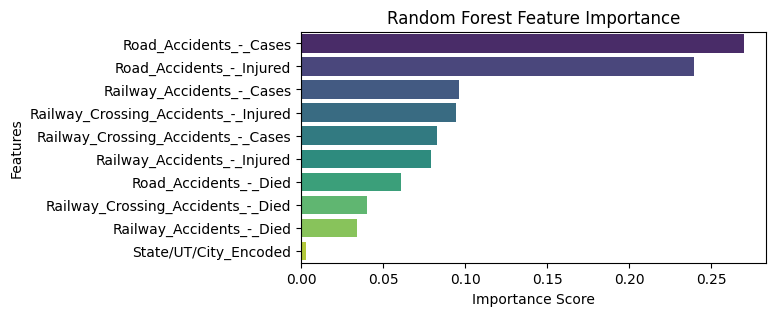

In [ ]:
plt.figure(figsize=(6,3))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis'
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

**Training Score Vs Testing Score**

In [ ]:
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)
print("Training R² Score :", train_score)
print("Testing R² Score :", test_score)

Training R² Score : 0.8063856229267993
Testing R² Score : 0.8054646066088731


**As the difference between Training and Testing Score is negligible, hence its a good generalization and it has prevented Overfitting.**

### **(d) XGBoost Regression Model**

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    objective='reg:squarederror'
)
xgb_model.fit(X_train, y_train)
print("XGBoost Regression Model Trained Successfully")

XGBoost Regression Model Trained Successfully


In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

**Evaluation of Model**

In [ ]:
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regression Results")
print("-"*40)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2_xgb)

XGBoost Regression Results
----------------------------------------
MAE : 22699.34765625
MSE : 8040808448.0
RMSE : 89670.55507801878
R² Score : 0.21452665328979492


**Actual Vs Predicted Plot**

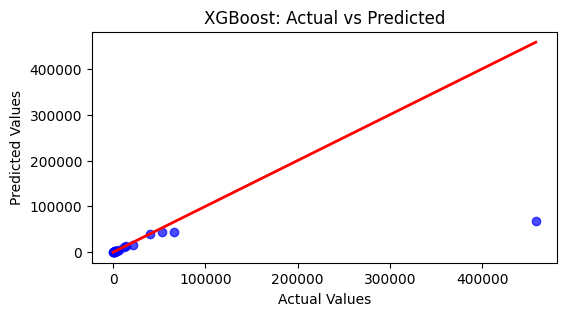

In [ ]:
plt.figure(figsize=(6,3))

plt.scatter(
    y_test,
    y_pred_xgb,
    color='blue',
    alpha=0.7
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

**Residual Plot**

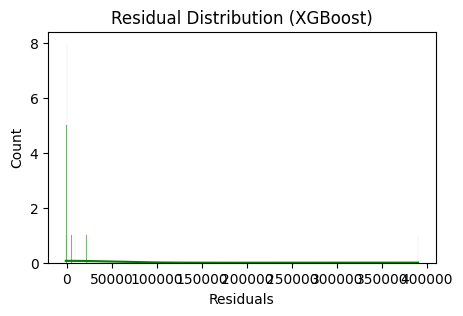

In [ ]:
residuals_xgb = y_test - y_pred_xgb
plt.figure(figsize=(5,3))
sns.histplot(
    residuals_xgb,
    kde=True,
    color='green'
)
plt.title("Residual Distribution (XGBoost)")
plt.xlabel("Residuals")
plt.show()

**Residual Scatter Plot**

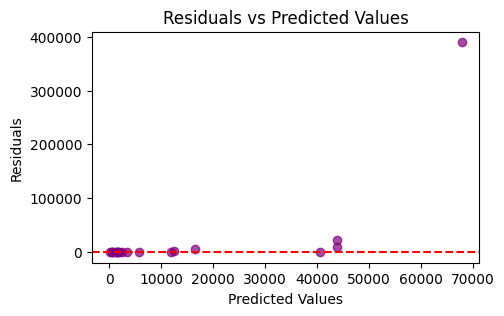

In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(
    y_pred_xgb,
    residuals_xgb,
    color='purple',
    alpha=0.7
)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

**Feature Importance**

In [ ]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})
feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance_xgb)

                                Feature  Importance
0                Road_Accidents_-_Cases    0.993497
2                 Road_Accidents_-_Died    0.004702
3             Railway_Accidents_-_Cases    0.001419
1              Road_Accidents_-_Injured    0.000161
9                 State/UT/City_Encoded    0.000113
4           Railway_Accidents_-_Injured    0.000098
6    Railway_Crossing_Accidents_-_Cases    0.000006
5              Railway_Accidents_-_Died    0.000004
7  Railway_Crossing_Accidents_-_Injured    0.000000
8     Railway_Crossing_Accidents_-_Died    0.000000


**Feature Importance Plot**

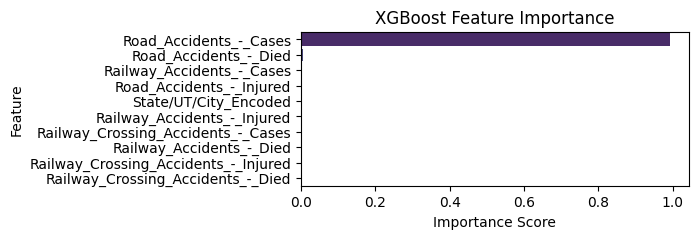

In [ ]:
plt.figure(figsize=(5,2))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_xgb,
    palette='viridis'
)
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

**Training Score Vs Testing Score**

In [ ]:
train_score = xgb_model.score(
    X_train,
    y_train
)
test_score = xgb_model.score(
    X_test,
    y_test
)
print("Training R² Score :", train_score)
print("Testing R² Score :", test_score)

Training R² Score : 0.9999661445617676
Testing R² Score : 0.21452665328979492


### **Hyperparameter Tuning for XGB Regressor Model**

In [ ]:
param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [3,4,5],
    'learning_rate': [0.01,0.05,0.1]
}
grid = GridSearchCV(
    XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='r2'
)
grid.fit(X_train, y_train)
print("Best Parameters:")
print(grid.best_params_)
print("Best Score:")
print(grid.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best Score:
0.7508164167404174


### **(e) Extra Trees Regression Model**

In [ ]:
et_model = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
et_model.fit(X_train, y_train)
print("Extra Trees Regressor Model Trained Successfully")

Extra Trees Regressor Model Trained Successfully


In [ ]:
y_pred_et = et_model.predict(X_test)

**Evaluation of Model**

In [ ]:
mae = mean_absolute_error(
    y_test,
    y_pred_et
)
mse = mean_squared_error(
    y_test,
    y_pred_et
)
rmse = np.sqrt(mse)
r2_et = r2_score(
    y_test,
    y_pred_et
)
print("Extra Trees Regression Results")
print("-"*40)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2_et)

Extra Trees Regression Results
----------------------------------------
MAE : 606.4818421052635
MSE : 1388566.9896013166
RMSE : 1178.3747237620623
R² Score : 0.9998643566281907


**Actual Vs Predicted Plot**

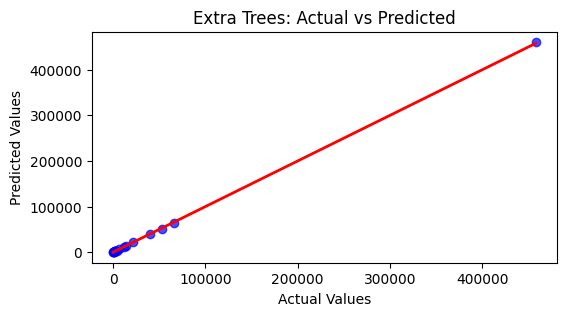

In [ ]:
plt.figure(figsize=(6,3))

plt.scatter(
    y_test,
    y_pred_et,
    alpha=0.7,
    color='blue'
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Extra Trees: Actual vs Predicted")
plt.show()

**Residual Distribution Plot**

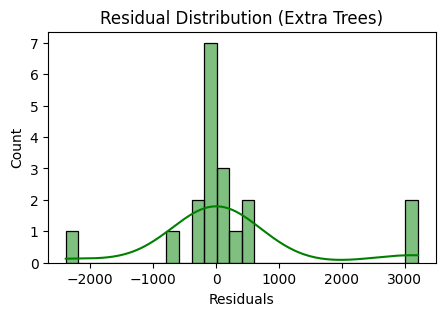

In [ ]:
residuals_et = y_test - y_pred_et
plt.figure(figsize=(5,3))
sns.histplot(
    residuals_et,
    kde=True,
    color='green'
)
plt.title("Residual Distribution (Extra Trees)")
plt.xlabel("Residuals")
plt.show()

**Residual Scatter Plot**

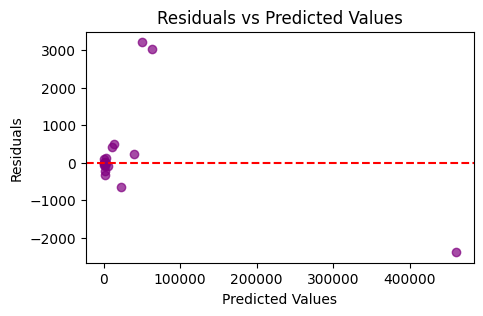

In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(
    y_pred_et,
    residuals_et,
    alpha=0.7,
    color='purple'
)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

**Prediction Error Plot**

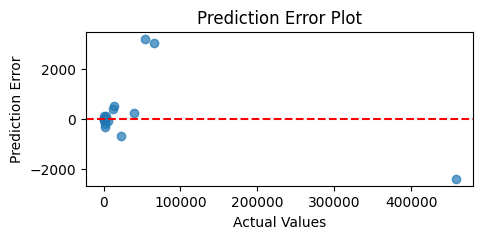

In [ ]:
errors = y_test - y_pred_et
plt.figure(figsize=(5,2))
plt.scatter(
    y_test,
    errors,
    alpha=0.7
)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)
plt.xlabel("Actual Values")
plt.ylabel("Prediction Error")
plt.title("Prediction Error Plot")
plt.show()

**Feature Importance**

In [ ]:
feature_importance_et = pd.DataFrame({
    'Feature': X.columns,
    'Importance': et_model.feature_importances_
})
feature_importance_et = feature_importance_et.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance_et)

                                Feature  Importance
5              Railway_Accidents_-_Died    0.154468
3             Railway_Accidents_-_Cases    0.153830
0                Road_Accidents_-_Cases    0.153417
2                 Road_Accidents_-_Died    0.152879
1              Road_Accidents_-_Injured    0.139440
7  Railway_Crossing_Accidents_-_Injured    0.096177
6    Railway_Crossing_Accidents_-_Cases    0.077073
8     Railway_Crossing_Accidents_-_Died    0.057944
4           Railway_Accidents_-_Injured    0.014684
9                 State/UT/City_Encoded    0.000088


**Feature Importance Plot**

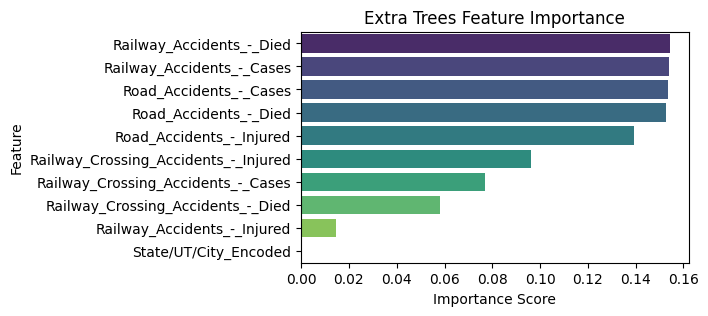

In [ ]:
plt.figure(figsize=(5,3))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_et,
    palette='viridis'
)
plt.title("Extra Trees Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

**Training Score Vs Testing Score**

In [ ]:
train_score = et_model.score(
    X_train,
    y_train
)
test_score = et_model.score(
    X_test,
    y_test
)
print("Training R² Score :", train_score)
print("Testing R² Score :", test_score)

Training R² Score : 1.0
Testing R² Score : 0.9998643566281907


**As the difference between Training and Testing Score is negligible, hence its an excellent fit and a good generalization and it has prevented Overfitting.**

### **Hyperparameter Tuning for Extra Trees Regressor Model**

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}
grid = GridSearchCV(
    ExtraTreesRegressor(
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train, y_train)
print("Best Parameters:")
print(grid.best_params_)
print("Best CV Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score:
-0.23671821378062527


**Model Comparison Table**

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Random Forest',
        'XGBoost',
        'Extra Trees'
    ],
    'R2 Score': [
        r2_linear,
        r2_ridge,
        r2_random,
        r2_xgb,
        r2_et
    ]
})
print(results.sort_values(
    by='R2 Score',
    ascending=False
))

               Model  R2 Score
0  Linear Regression  1.000000
1   Ridge Regression  1.000000
4        Extra Trees  0.999864
2      Random Forest  0.805465
3            XGBoost  0.214527


## **Model Building(Clustering)**

In [ ]:
cluster_features = [
    'Road_Accidents_-_Cases',
    'Road_Accidents_-_Injured',
    'Road_Accidents_-_Died',

    'Railway_Accidents_-_Cases',
    'Railway_Accidents_-_Injured',
    'Railway_Accidents_-_Died',

    'Railway_Crossing_Accidents_-_Cases',
    'Railway_Crossing_Accidents_-_Injured',
    'Railway_Crossing_Accidents_-_Died'
]
X_cluster = data[cluster_features]

### **Feature Scaling(using Standard Scaler)**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print(X_scaled.shape)

(93, 9)


### **Elbow Method(KMeans)**

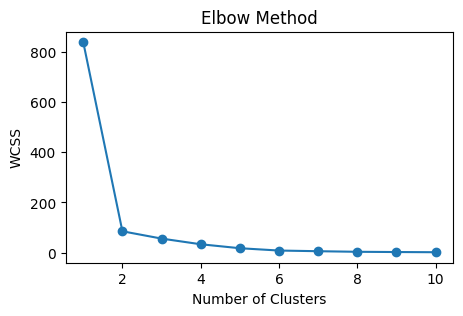

In [ ]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(5,3))
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### **Silhouette Score**

In [ ]:
for k in range(2,10):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        labels
    )
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.9645
K=3, Silhouette Score=0.8637
K=4, Silhouette Score=0.8776
K=5, Silhouette Score=0.8692
K=6, Silhouette Score=0.8042
K=7, Silhouette Score=0.7467
K=8, Silhouette Score=0.7408
K=9, Silhouette Score=0.7413


### **Training Part(KMeans)**

In [38]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

data['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(data[['State/UT/City',
          'KMeans_Cluster']].head())

       State/UT/City  KMeans_Cluster
0     Andhra Pradesh               0
1  Arunachal Pradesh               0
2              Assam               0
3              Bihar               0
4       Chhattisgarh               0


### **Cluster Distribution**

In [40]:
print(
    data['KMeans_Cluster']
    .value_counts()
)

KMeans_Cluster
0    88
2     3
1     2
Name: count, dtype: int64


### **Visualize KMeans Clusters using PCA**

In [44]:
pca = PCA(
    n_components=2,
    random_state=42
)
X_pca = pca.fit_transform(X_scaled)
pca_data = pd.DataFrame(
    X_pca,
    columns=['PC1','PC2']
)
pca_data['Cluster'] = data['KMeans_Cluster']

### **KMeans Cluster Plot**

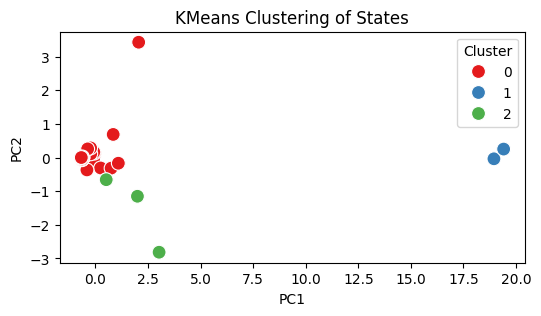

In [48]:
plt.figure(figsize=(6,3))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    data=pca_data,
    s=100
)
plt.title("KMeans Clustering of States")
plt.show()

### **Cluster-wise Statistics**

In [50]:
cluster_summary = data.groupby(
    'KMeans_Cluster'
)[cluster_features].mean()

print(cluster_summary)

                Road_Accidents_-_Cases  Road_Accidents_-_Injured  \
KMeans_Cluster                                                     
0                          6068.818182               5825.295455   
1                        439939.500000             415519.500000   
2                         19724.333333              13363.000000   

                Road_Accidents_-_Died  Railway_Accidents_-_Cases  \
KMeans_Cluster                                                     
0                         1936.329545                 246.375000   
1                       169735.000000               22712.000000   
2                        11789.000000                1812.666667   

                Railway_Accidents_-_Injured  Railway_Accidents_-_Died  \
KMeans_Cluster                                                          
0                                    27.875                219.284091   
1                                  2403.500              20417.500000   
2                         

### **Identify High-Risk States**

In [53]:
high_risk = data[
    data['KMeans_Cluster'] ==
    data['KMeans_Cluster'].value_counts().idxmax()
]

print(
    high_risk[
        ['State/UT/City',
         'KMeans_Cluster']
    ]
)

        State/UT/City  KMeans_Cluster
0      Andhra Pradesh               0
1   Arunachal Pradesh               0
2               Assam               0
3               Bihar               0
4        Chhattisgarh               0
..                ...             ...
88           Varanasi               0
89        Vasai Virar               0
90         Vijayawada               0
91     Vishakhapatnam               0
92     Total (Cities)               0

[88 rows x 2 columns]


## **Hierarchical Clustering**

### **Creating Linkage Matrix**

In [54]:
linked = linkage(
    X_scaled,
    method='ward'
)

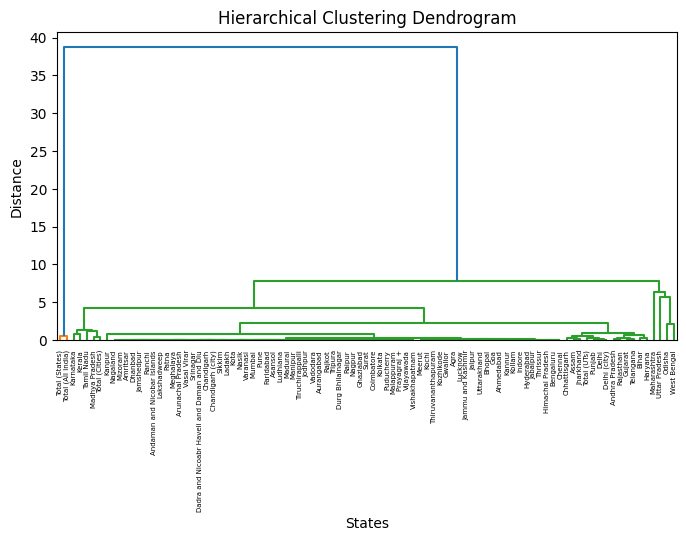

In [56]:
plt.figure(figsize=(8,4))
dendrogram(
    linked,
    labels=data['State/UT/City'].values,
    leaf_rotation=90
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("States")
plt.ylabel("Distance")
plt.show()

### **Training Part(Agglomerative Clustering)**

In [59]:
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)
data['Hierarchical_Cluster'] = hc.fit_predict(
    X_scaled
)

### **View Cluster Assignments**

In [61]:
print(
    data[
        [
            'State/UT/City',
            'Hierarchical_Cluster'
        ]
    ].head()
)

       State/UT/City  Hierarchical_Cluster
0     Andhra Pradesh                     2
1  Arunachal Pradesh                     2
2              Assam                     2
3              Bihar                     2
4       Chhattisgarh                     2


### **Visualize Hierarchical Clusters**

In [62]:
pca_data['Hierarchical_Cluster'] = (
    data['Hierarchical_Cluster']
)

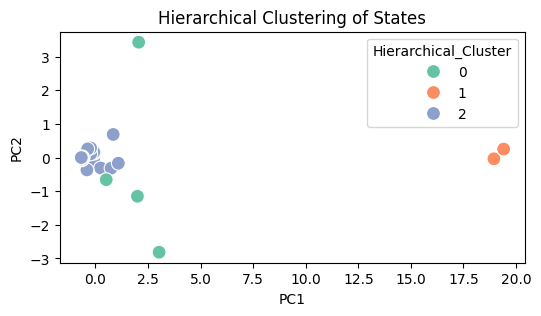

In [65]:
plt.figure(figsize=(6,3))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Hierarchical_Cluster',
    palette='Set2',
    data=pca_data,
    s=100
)
plt.title(
    "Hierarchical Clustering of States"
)
plt.show()

### **Hierarchical Cluster Summary**

In [68]:
hier_summary = data.groupby(
    'Hierarchical_Cluster'
)[cluster_features].mean()

print(hier_summary)

                      Road_Accidents_-_Cases  Road_Accidents_-_Injured  \
Hierarchical_Cluster                                                     
0                               22429.750000              15991.750000   
1                              439939.500000             415519.500000   
2                                5787.471264               5617.793103   

                      Road_Accidents_-_Died  Railway_Accidents_-_Cases  \
Hierarchical_Cluster                                                     
0                              12778.750000                2566.250000   
1                             169735.000000               22712.000000   
2                               1777.574713                 193.724138   

                      Railway_Accidents_-_Injured  Railway_Accidents_-_Died  \
Hierarchical_Cluster                                                          
0                                      501.750000               2068.250000   
1                    

### **Compare KMeans Vs Hierarchical**

In [73]:
comparison = data[
    [
        'State/UT/City',
        'KMeans_Cluster',
        'Hierarchical_Cluster'
    ]
]
print(comparison.head(28))

        State/UT/City  KMeans_Cluster  Hierarchical_Cluster
0      Andhra Pradesh               0                     2
1   Arunachal Pradesh               0                     2
2               Assam               0                     2
3               Bihar               0                     2
4        Chhattisgarh               0                     2
5                 Goa               0                     2
6             Gujarat               0                     2
7             Haryana               0                     2
8    Himachal Pradesh               0                     2
9           Jharkhand               0                     2
10          Karnataka               0                     2
11             Kerala               0                     2
12     Madhya Pradesh               0                     2
13        Maharashtra               0                     0
14            Manipur               0                     2
15          Meghalaya               0   